**Link to Data**

https://www.kaggle.com/datasets/noeyislearning/vinho-verde-white-wine-quality?resource=download

**Loading the Data**

In [5]:
import pandas as pd

# Load the dataset
file_path = 'data.csv'
data = pd.read_csv(file_path)

**Handle Missing Values**

In [6]:
from sklearn.impute import SimpleImputer

# Handle missing values by imputing with the median
num_imputer = SimpleImputer(strategy='median')
data = pd.DataFrame(num_imputer.fit_transform(data), columns=data.columns)


**Remove Outliers**

In [7]:
# Remove outliers using the IQR method
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# Define a mask for filtering out outliers
mask = ~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)

# Filter the data to remove outliers
data = data[mask]
print(data.shape)

(3858, 12)


**Split into Train & Test sets**

In [8]:
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
train_set, test_set = train_test_split(data, test_size=0.2, random_state=42)

# Separate features and target variable from training set
X_train = train_set.drop('quality', axis=1)
y_train = train_set['quality']

**Preparing & Training**

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, explained_variance_score
import time
import tracemalloc
import numpy as np

# STDV of data
std_dev = np.std(y_train)

# Evaluate resource utilization for Linear Regression model
tracemalloc.start()
start_time = time.time()

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

lin_reg_time = end_time - start_time
lin_reg_memory = peak / 10**6  # Convert to MB




# Predict using the Linear Regression model on the training set
y_pred_lin_reg = lin_reg.predict(X_train)

# Calculate performance metrics for Linear Regression model
rmse_lin_reg = np.sqrt(mean_squared_error(y_train, y_pred_lin_reg))/std_dev
r2_lin_reg = r2_score(y_train, y_pred_lin_reg)
mae_lin_reg = mean_absolute_error(y_train, y_pred_lin_reg)
evs_lin_reg = explained_variance_score(y_train, y_pred_lin_reg)




# Evaluate resource utilization for K-Nearest Neighbors (KNN) Regressor model
tracemalloc.start()
start_time = time.time()

knn_reg = KNeighborsRegressor()
knn_reg.fit(X_train, y_train)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

knn_reg_time = end_time - start_time
knn_reg_memory = peak / 10**6  # Convert to MB




# Predict using the KNN Regressor model on the training set
y_pred_knn_reg = knn_reg.predict(X_train)

# Calculate performance metrics for KNN Regressor model
rmse_knn_reg = np.sqrt(mean_squared_error(y_train, y_pred_knn_reg))/std_dev
r2_knn_reg = r2_score(y_train, y_pred_knn_reg)
mae_knn_reg = mean_absolute_error(y_train, y_pred_knn_reg)
evs_knn_reg = explained_variance_score(y_train, y_pred_knn_reg)

print("Linear Regression Performance Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_lin_reg}")
print(f"R-squared (R2): {r2_lin_reg}")
print(f"Mean Absolute Error (MAE): {mae_lin_reg}")
print(f"Explained Variance Score (EVS): {evs_lin_reg}")

print("\nK-Nearest Neighbors (KNN) Regressor Performance Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_knn_reg}")
print(f"R-squared (R2): {r2_knn_reg}")
print(f"Mean Absolute Error (MAE): {mae_knn_reg}")
print(f"Explained Variance Score (EVS): {evs_knn_reg}")


print(f"\nLinear Regression Training Time: {lin_reg_time} seconds")
print(f"Linear Regression Memory Usage: {lin_reg_memory} MB")

print(f"\nK-Nearest Neighbors (KNN) Regressor Training Time: {knn_reg_time} seconds")
print(f"K-Nearest Neighbors (KNN) Regressor Memory Usage: {knn_reg_memory} MB")

Linear Regression Performance Metrics:
Root Mean Squared Error (RMSE): 0.8643399832605703
R-squared (R2): 0.25291639333711124
Mean Absolute Error (MAE): 0.5188471838420928
Explained Variance Score (EVS): 0.25291639333711124

K-Nearest Neighbors (KNN) Regressor Performance Metrics:
Root Mean Squared Error (RMSE): 0.7451292479355495
R-squared (R2): 0.444782403870998
Mean Absolute Error (MAE): 0.429552819183409
Explained Variance Score (EVS): 0.4448766908604045

Linear Regression Training Time: 0.12947487831115723 seconds
Linear Regression Memory Usage: 0.628968 MB

K-Nearest Neighbors (KNN) Regressor Training Time: 0.02544569969177246 seconds
K-Nearest Neighbors (KNN) Regressor Memory Usage: 0.350648 MB


**Some Visuals**

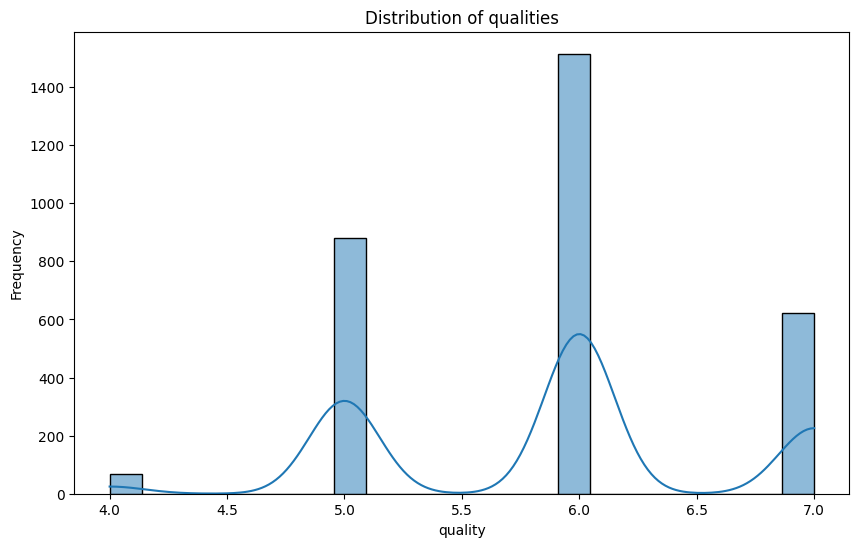

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of qualites
plt.figure(figsize=(10, 6))
sns.histplot(y_train, kde=True)
plt.title('Distribution of qualities')
plt.xlabel('quality')
plt.ylabel('Frequency')
plt.show()

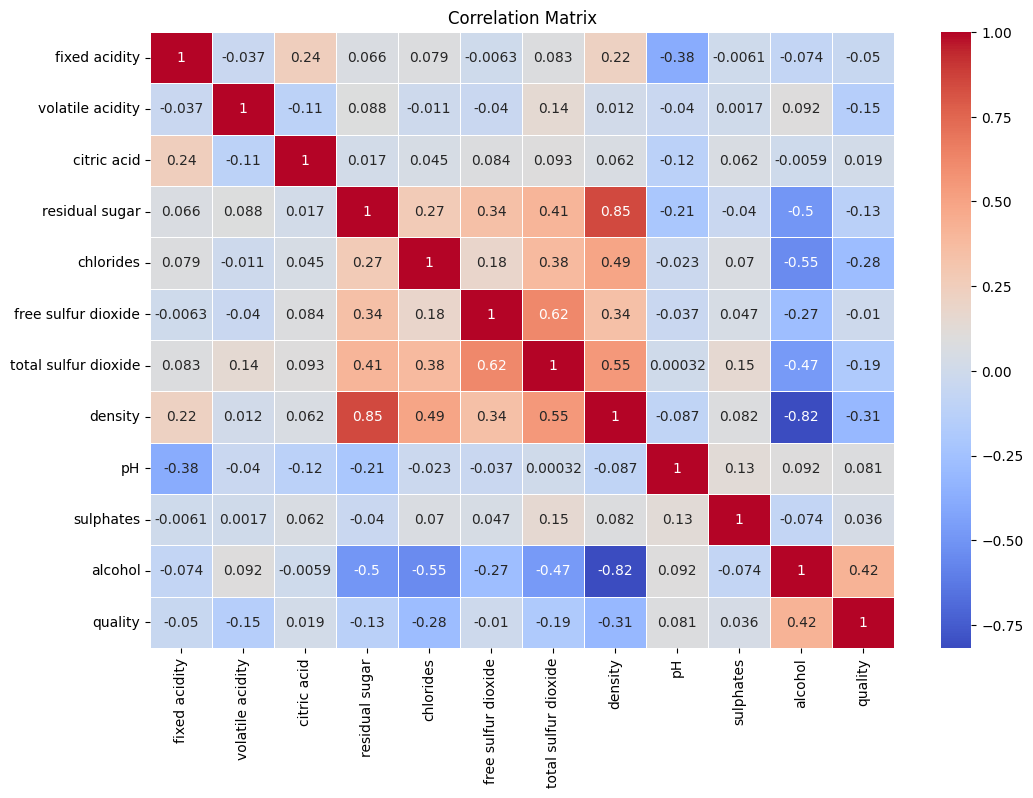

In [11]:
# Visualize the correlation matrix

set_concatenated = pd.concat([X_train, y_train], axis=1)

plt.figure(figsize=(12, 8))
correlation_matrix = set_concatenated.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [12]:
import matplotlib.pyplot as plt

# Create a multi scatter plot (pairplot) of the data
plt.figure(figsize=(12, 8))
sns.pairplot(set_concatenated)
plt.title('Multi Scatter Plot of the Data')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [13]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor

# Gradient Boosting Regressor
tracemalloc.start()
start_time = time.time()

gradient_boosting_reg = GradientBoostingRegressor()
gradient_boosting_reg.fit(X_train, y_train)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

gradient_boosting_training_time = end_time - start_time
gradient_boosting_memory_usage = peak / 10**6  # Convert to MB

# Predict using the Gradient Boosting Regressor
y_pred_gradient_boosting = gradient_boosting_reg.predict(X_train)

# Calculate performance metrics for Gradient Boosting Regressor
rmse_gradient_boosting = np.sqrt(mean_squared_error(y_train, y_pred_gradient_boosting))/std_dev
r2_gradient_boosting = r2_score(y_train, y_pred_gradient_boosting)
mae_gradient_boosting = mean_absolute_error(y_train, y_pred_gradient_boosting)
evs_gradient_boosting = explained_variance_score(y_train, y_pred_gradient_boosting)


# Random Forest Regressor
tracemalloc.start()
start_time = time.time()

random_forest_reg = RandomForestRegressor()
random_forest_reg.fit(X_train, y_train)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

random_forest_training_time = end_time - start_time
random_forest_memory_usage = peak / 10**6  # Convert to MB

# Predict using the Random Forest Regressor
y_pred_random_forest = random_forest_reg.predict(X_train)

# Calculate performance metrics for Random Forest Regressor
rmse_random_forest = np.sqrt(mean_squared_error(y_train, y_pred_random_forest))/std_dev
r2_random_forest = r2_score(y_train, y_pred_random_forest)
mae_random_forest = mean_absolute_error(y_train, y_pred_random_forest)
evs_random_forest = explained_variance_score(y_train, y_pred_random_forest)


# Print Gradient Boosting Regressor results
print("Gradient Boosting Regressor Performance Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_gradient_boosting}")
print(f"R-squared (R2): {r2_gradient_boosting}")
print(f"Mean Absolute Error (MAE): {mae_gradient_boosting}")
print(f"Explained Variance Score (EVS): {evs_gradient_boosting}")
print(f"Training Time: {gradient_boosting_training_time} seconds")
print(f"Memory Usage: {gradient_boosting_memory_usage} MB")


# Print Random Forest Regressor results
print("Random Forest Regressor Performance Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_random_forest}")
print(f"R-squared (R2): {r2_random_forest}")
print(f"Mean Absolute Error (MAE): {mae_random_forest}")
print(f"Explained Variance Score (EVS): {evs_random_forest}")
print(f"Training Time: {random_forest_training_time} seconds")
print(f"Memory Usage: {random_forest_memory_usage} MB")

Gradient Boosting Regressor Performance Metrics:
Root Mean Squared Error (RMSE): 0.7209034139057656
R-squared (R2): 0.4802982678190083
Mean Absolute Error (MAE): 0.43114988027022344
Explained Variance Score (EVS): 0.4802982678190083
Training Time: 1.6734678745269775 seconds
Memory Usage: 0.410113 MB
Random Forest Regressor Performance Metrics:
Root Mean Squared Error (RMSE): 0.2626495552906365
R-squared (R2): 0.9310152111056303
Mean Absolute Error (MAE): 0.1425534672715489
Explained Variance Score (EVS): 0.931015384285815
Training Time: 3.935685873031616 seconds
Memory Usage: 0.407685 MB


**Automatic Feature Engineering**

In [14]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_p = poly.fit_transform(X_train)

print(X_train_p.shape)


# Evaluate resource utilization for Linear Regression model
tracemalloc.start()
start_time = time.time()

lin_reg = LinearRegression()
lin_reg.fit(X_train_p, y_train)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

lin_reg_time = end_time - start_time
lin_reg_memory = peak / 10**6  # Convert to MB




# Predict using the Linear Regression model on the training set
y_pred_lin_reg = lin_reg.predict(X_train_p)

# Calculate performance metrics for Linear Regression model
rmse_lin_reg = np.sqrt(mean_squared_error(y_train, y_pred_lin_reg))/std_dev
r2_lin_reg = r2_score(y_train, y_pred_lin_reg)
mae_lin_reg = mean_absolute_error(y_train, y_pred_lin_reg)
evs_lin_reg = explained_variance_score(y_train, y_pred_lin_reg)




# Evaluate resource utilization for K-Nearest Neighbors (KNN) Regressor model
tracemalloc.start()
start_time = time.time()

knn_reg = KNeighborsRegressor()
knn_reg.fit(X_train_p, y_train)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

knn_reg_time = end_time - start_time
knn_reg_memory = peak / 10**6  # Convert to MB




# Predict using the KNN Regressor model on the training set
y_pred_knn_reg = knn_reg.predict(X_train_p)

# Calculate performance metrics for KNN Regressor model
rmse_knn_reg = np.sqrt(mean_squared_error(y_train, y_pred_knn_reg))/std_dev
r2_knn_reg = r2_score(y_train, y_pred_knn_reg)
mae_knn_reg = mean_absolute_error(y_train, y_pred_knn_reg)
evs_knn_reg = explained_variance_score(y_train, y_pred_knn_reg)

print("Linear Regression Performance Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_lin_reg}")
print(f"R-squared (R2): {r2_lin_reg}")
print(f"Mean Absolute Error (MAE): {mae_lin_reg}")
print(f"Explained Variance Score (EVS): {evs_lin_reg}")

print("\nK-Nearest Neighbors (KNN) Regressor Performance Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_knn_reg}")
print(f"R-squared (R2): {r2_knn_reg}")
print(f"Mean Absolute Error (MAE): {mae_knn_reg}")
print(f"Explained Variance Score (EVS): {evs_knn_reg}")


print(f"\nLinear Regression Training Time: {lin_reg_time} seconds")
print(f"Linear Regression Memory Usage: {lin_reg_memory} MB")

print(f"\nK-Nearest Neighbors (KNN) Regressor Training Time: {knn_reg_time} seconds")
print(f"K-Nearest Neighbors (KNN) Regressor Memory Usage: {knn_reg_memory} MB\n")





# Gradient Boosting Regressor
tracemalloc.start()
start_time = time.time()

gradient_boosting_reg = GradientBoostingRegressor()
gradient_boosting_reg.fit(X_train_p, y_train)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

gradient_boosting_training_time = end_time - start_time
gradient_boosting_memory_usage = peak / 10**6  # Convert to MB

# Predict using the Gradient Boosting Regressor
y_pred_gradient_boosting = gradient_boosting_reg.predict(X_train_p)

# Calculate performance metrics for Gradient Boosting Regressor
rmse_gradient_boosting = np.sqrt(mean_squared_error(y_train, y_pred_gradient_boosting))/std_dev
r2_gradient_boosting = r2_score(y_train, y_pred_gradient_boosting)
mae_gradient_boosting = mean_absolute_error(y_train, y_pred_gradient_boosting)
evs_gradient_boosting = explained_variance_score(y_train, y_pred_gradient_boosting)


# Random Forest Regressor
tracemalloc.start()
start_time = time.time()

random_forest_reg = RandomForestRegressor()
random_forest_reg.fit(X_train_p, y_train)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

random_forest_training_time = end_time - start_time
random_forest_memory_usage = peak / 10**6  # Convert to MB

# Predict using the Random Forest Regressor
y_pred_random_forest = random_forest_reg.predict(X_train_p)

# Calculate performance metrics for Random Forest Regressor
rmse_random_forest = np.sqrt(mean_squared_error(y_train, y_pred_random_forest))/std_dev
r2_random_forest = r2_score(y_train, y_pred_random_forest)
mae_random_forest = mean_absolute_error(y_train, y_pred_random_forest)
evs_random_forest = explained_variance_score(y_train, y_pred_random_forest)


# Print Gradient Boosting Regressor results
print("Gradient Boosting Regressor Performance Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_gradient_boosting}")
print(f"R-squared (R2): {r2_gradient_boosting}")
print(f"Mean Absolute Error (MAE): {mae_gradient_boosting}")
print(f"Explained Variance Score (EVS): {evs_gradient_boosting}")
print(f"Training Time: {gradient_boosting_training_time} seconds")
print(f"Memory Usage: {gradient_boosting_memory_usage} MB\n")


# Print Random Forest Regressor results
print("Random Forest Regressor Performance Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_random_forest}")
print(f"R-squared (R2): {r2_random_forest}")
print(f"Mean Absolute Error (MAE): {mae_random_forest}")
print(f"Explained Variance Score (EVS): {evs_random_forest}")
print(f"Training Time: {random_forest_training_time} seconds")
print(f"Memory Usage: {random_forest_memory_usage} MB")


(3086, 77)
Linear Regression Performance Metrics:
Root Mean Squared Error (RMSE): 0.8060457627703985
R-squared (R2): 0.35029022831988144
Mean Absolute Error (MAE): 0.48279082652182226
Explained Variance Score (EVS): 0.35029022831988144

K-Nearest Neighbors (KNN) Regressor Performance Metrics:
Root Mean Squared Error (RMSE): 0.7657932537848153
R-squared (R2): 0.4135606924576609
Mean Absolute Error (MAE): 0.4453661697990927
Explained Variance Score (EVS): 0.41372091419444246

Linear Regression Training Time: 0.01822686195373535 seconds
Linear Regression Memory Usage: 3.919518 MB

K-Nearest Neighbors (KNN) Regressor Training Time: 0.0044972896575927734 seconds
K-Nearest Neighbors (KNN) Regressor Memory Usage: 0.072369 MB

Gradient Boosting Regressor Performance Metrics:
Root Mean Squared Error (RMSE): 0.6756662762797911
R-squared (R2): 0.5434750830981974
Mean Absolute Error (MAE): 0.4062020000702199
Explained Variance Score (EVS): 0.5434750830981973
Training Time: 7.39458441734314 seconds

**Manual Feature Engineering**

In [15]:
# Create new features
X_train['Acidity_Ratio'] = X_train['fixed acidity'] / X_train['volatile acidity']
X_train['Sulfur_Dioxide_Ratio'] = X_train['free sulfur dioxide'] / X_train['total sulfur dioxide']
X_train['Density_Alcohol_Interaction'] = X_train['density'] * X_train['alcohol']



# Evaluate resource utilization for Linear Regression model
tracemalloc.start()
start_time = time.time()

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

lin_reg_time = end_time - start_time
lin_reg_memory = peak / 10**6  # Convert to MB




# Predict using the Linear Regression model on the training set
y_pred_lin_reg = lin_reg.predict(X_train)

# Calculate performance metrics for Linear Regression model
rmse_lin_reg = np.sqrt(mean_squared_error(y_train, y_pred_lin_reg))/std_dev
r2_lin_reg = r2_score(y_train, y_pred_lin_reg)
mae_lin_reg = mean_absolute_error(y_train, y_pred_lin_reg)
evs_lin_reg = explained_variance_score(y_train, y_pred_lin_reg)




# Evaluate resource utilization for K-Nearest Neighbors (KNN) Regressor model
tracemalloc.start()
start_time = time.time()

knn_reg = KNeighborsRegressor()
knn_reg.fit(X_train, y_train)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

knn_reg_time = end_time - start_time
knn_reg_memory = peak / 10**6  # Convert to MB




# Predict using the KNN Regressor model on the training set
y_pred_knn_reg = knn_reg.predict(X_train)

# Calculate performance metrics for KNN Regressor model
rmse_knn_reg = np.sqrt(mean_squared_error(y_train, y_pred_knn_reg))/std_dev
r2_knn_reg = r2_score(y_train, y_pred_knn_reg)
mae_knn_reg = mean_absolute_error(y_train, y_pred_knn_reg)
evs_knn_reg = explained_variance_score(y_train, y_pred_knn_reg)

print("Linear Regression Performance Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_lin_reg}")
print(f"R-squared (R2): {r2_lin_reg}")
print(f"Mean Absolute Error (MAE): {mae_lin_reg}")
print(f"Explained Variance Score (EVS): {evs_lin_reg}")

print("\nK-Nearest Neighbors (KNN) Regressor Performance Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_knn_reg}")
print(f"R-squared (R2): {r2_knn_reg}")
print(f"Mean Absolute Error (MAE): {mae_knn_reg}")
print(f"Explained Variance Score (EVS): {evs_knn_reg}")


print(f"\nLinear Regression Training Time: {lin_reg_time} seconds")
print(f"Linear Regression Memory Usage: {lin_reg_memory} MB")

print(f"\nK-Nearest Neighbors (KNN) Regressor Training Time: {knn_reg_time} seconds")
print(f"K-Nearest Neighbors (KNN) Regressor Memory Usage: {knn_reg_memory} MB\n")






# Gradient Boosting Regressor
tracemalloc.start()
start_time = time.time()

gradient_boosting_reg = GradientBoostingRegressor()
gradient_boosting_reg.fit(X_train, y_train)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

gradient_boosting_training_time = end_time - start_time
gradient_boosting_memory_usage = peak / 10**6  # Convert to MB

# Predict using the Gradient Boosting Regressor
y_pred_gradient_boosting = gradient_boosting_reg.predict(X_train)

# Calculate performance metrics for Gradient Boosting Regressor
rmse_gradient_boosting = np.sqrt(mean_squared_error(y_train, y_pred_gradient_boosting))/std_dev
r2_gradient_boosting = r2_score(y_train, y_pred_gradient_boosting)
mae_gradient_boosting = mean_absolute_error(y_train, y_pred_gradient_boosting)
evs_gradient_boosting = explained_variance_score(y_train, y_pred_gradient_boosting)


# Random Forest Regressor
tracemalloc.start()
start_time = time.time()

random_forest_reg = RandomForestRegressor()
random_forest_reg.fit(X_train, y_train)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

random_forest_training_time = end_time - start_time
random_forest_memory_usage = peak / 10**6  # Convert to MB

# Predict using the Random Forest Regressor
y_pred_random_forest = random_forest_reg.predict(X_train)

# Calculate performance metrics for Random Forest Regressor
rmse_random_forest = np.sqrt(mean_squared_error(y_train, y_pred_random_forest))/std_dev
r2_random_forest = r2_score(y_train, y_pred_random_forest)
mae_random_forest = mean_absolute_error(y_train, y_pred_random_forest)
evs_random_forest = explained_variance_score(y_train, y_pred_random_forest)


# Print Gradient Boosting Regressor results
print("Gradient Boosting Regressor Performance Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_gradient_boosting}")
print(f"R-squared (R2): {r2_gradient_boosting}")
print(f"Mean Absolute Error (MAE): {mae_gradient_boosting}")
print(f"Explained Variance Score (EVS): {evs_gradient_boosting}")
print(f"Training Time: {gradient_boosting_training_time} seconds")
print(f"Memory Usage: {gradient_boosting_memory_usage} MB\n")


# Print Random Forest Regressor results
print("Random Forest Regressor Performance Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_random_forest}")
print(f"R-squared (R2): {r2_random_forest}")
print(f"Mean Absolute Error (MAE): {mae_random_forest}")
print(f"Explained Variance Score (EVS): {evs_random_forest}")
print(f"Training Time: {random_forest_training_time} seconds")
print(f"Memory Usage: {random_forest_memory_usage} MB")


Linear Regression Performance Metrics:
Root Mean Squared Error (RMSE): 0.8515255042905133
R-squared (R2): 0.2749043155427813
Mean Absolute Error (MAE): 0.5162483372835486
Explained Variance Score (EVS): 0.2749043155427813

K-Nearest Neighbors (KNN) Regressor Performance Metrics:
Root Mean Squared Error (RMSE): 0.7385001862386857
R-squared (R2): 0.45461747492542215
Mean Absolute Error (MAE): 0.4186649384316267
Explained Variance Score (EVS): 0.4547019303314307

Linear Regression Training Time: 0.016008377075195312 seconds
Linear Regression Memory Usage: 0.789866 MB

K-Nearest Neighbors (KNN) Regressor Training Time: 0.03993058204650879 seconds
K-Nearest Neighbors (KNN) Regressor Memory Usage: 0.698034 MB

Gradient Boosting Regressor Performance Metrics:
Root Mean Squared Error (RMSE): 0.7162074172524218
R-squared (R2): 0.4870469354726116
Mean Absolute Error (MAE): 0.43081442761964484
Explained Variance Score (EVS): 0.48704693547261146
Training Time: 1.775287389755249 seconds
Memory Usag

**Random forest on test set without hyperparameter tuning**

In [17]:
# Separate features and target variable from test set
X_test = test_set.drop('quality', axis=1)
y_test = test_set['quality']

# Feature engineering
X_test['Acidity_Ratio'] = X_test['fixed acidity'] / X_test['volatile acidity']
X_test['Sulfur_Dioxide_Ratio'] = X_test['free sulfur dioxide'] / X_test['total sulfur dioxide']
X_test['Density_Alcohol_Interaction'] = X_test['density'] * X_test['alcohol']

random_forest_reg.fit(X_train, y_train)
y_pred_random_forest = random_forest_reg.predict(X_test)

# Calculate performance metrics
rmse_best_random_forest = np.sqrt(mean_squared_error(y_test, y_pred_random_forest))/std_dev
r2_best_random_forest = r2_score(y_test, y_pred_random_forest)
mae_best_random_forest = mean_absolute_error(y_test, y_pred_random_forest)
evs_best_random_forest = explained_variance_score(y_test, y_pred_random_forest)

# Print results
print("Random Forest Regressor Performance Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_best_random_forest}")
print(f"R-squared (R2): {r2_best_random_forest}")
print(f"Mean Absolute Error (MAE): {mae_best_random_forest}")
print(f"Explained Variance Score (EVS): {evs_best_random_forest}")


Random Forest Regressor Performance Metrics:
Root Mean Squared Error (RMSE): 0.7533062211251672
R-squared (R2): 0.48249042236242556
Mean Absolute Error (MAE): 0.42753886010362696
Explained Variance Score (EVS): 0.4826118833245706


**Hyperparameter Tuning for Random Forest Regressor**

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=random_forest_reg, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)





# Evaluate the tuned model
best_random_forest_reg = grid_search.best_estimator_
y_pred_best_random_forest = best_random_forest_reg.predict(X_test)

# Calculate performance metrics for the tuned model
rmse_best_random_forest = np.sqrt(mean_squared_error(y_test, y_pred_best_random_forest))/std_dev
r2_best_random_forest = r2_score(y_test, y_pred_best_random_forest)
mae_best_random_forest = mean_absolute_error(y_test, y_pred_best_random_forest)
evs_best_random_forest = explained_variance_score(y_test, y_pred_best_random_forest)

# Print the tuned model results
print("Tuned Random Forest Regressor Performance Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_best_random_forest}")
print(f"R-squared (R2): {r2_best_random_forest}")
print(f"Mean Absolute Error (MAE): {mae_best_random_forest}")
print(f"Explained Variance Score (EVS): {evs_best_random_forest}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Random Forest Regressor Performance Metrics:
Root Mean Squared Error (RMSE): 0.7583954861505346
R-squared (R2): 0.4754743113060813
Mean Absolute Error (MAE): 0.4298380829015544
Explained Variance Score (EVS): 0.47557109272312037
